In [42]:
# 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 텍스트 탐색용
import re
from collections import Counter

# 머신러닝 (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# 모델
from xgboost import XGBClassifier

# 희소 행렬(sparse matrix) 타입 확인용
from scipy import sparse

# 그래프에서 한글이 깨지지 않도록 폰트 설정 (Windows 기준: 맑은 고딕)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

#plt 그래프 스타일 설정
plt.style.use("ggplot")

# 노트북 안에서 그래프가 바로 보이도록 설정
%matplotlib inline

print("라이브러리 불러오기 완료")

라이브러리 불러오기 완료


In [43]:
# ---- 파일 경로 설정 ----
# 노트북과 같은 폴더에 있는 파일명을 기준으로 경로를 설정합니다.
# 파일을 다른 폴더에 저장했거나 파일명이 다르면, 아래 값을 실제 파일 위치에 맞게 수정합니다.
# 이후 코드들은 파일명을 직접 쓰지 않고 이 변수들을 사용하므로, 경로 변경은 이 셀만 수정하면 됩니다.
TRAIN_PATH = "security_log_train.csv"             # 학습 데이터 (로그 텍스트 + 정답 level)
TEST_PATH = "security_log_test.csv"               # 테스트 데이터 (정답 level 없음)
SAMPLE_SUBMISSION_PATH = "sample_submission.csv"  # 제출 양식
OUTPUT_PATH = "base_log2.csv"                     # 생성할 제출 파일

# ---- 실행 옵션 ----
# RANDOM_STATE: 결과 재현성을 위한 난수 시드입니다.
# 같은 시드를 사용하면 train/valid 분리나 모델 학습 결과가 매번 동일하게 재현됩니다.
RANDOM_STATE = 42

print("설정 완료 (전체 train 데이터를 사용합니다)")

설정 완료 (전체 train 데이터를 사용합니다)


In [44]:
# 위에서 정의한 경로 변수를 사용해 세 개의 데이터를 불러옵니다.
# train: 모델이 학습할 로그 텍스트(full_log)와 정답 라벨(level)이 들어 있습니다.
# test : 예측 대상 데이터입니다. 정답 level이 없으므로 우리가 예측해서 채웁니다.
# sample_submission: 제출 파일의 형식(행 개수, 컬럼)을 알려주는 양식입니다.
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

# 각 데이터의 행/열 개수를 확인합니다. (train과 test의 행 개수는 보통 다릅니다.)
print("train shape:", train.shape)
print("test shape :", test.shape)
print("sample_submission shape:", sample_submission.shape)

train shape: (472972, 3)
test shape : (1418916, 2)
sample_submission shape: (1418916, 2)


In [45]:
# ============================================================
# 모델 학습에 사용할 데이터 준비
# ============================================================

# 이 baseline에서는 전체 train 데이터를 사용합니다.
# 클래스 불균형이 매우 심한 데이터이므로,
# 일부 샘플만 뽑으면 희귀 클래스가 사라지거나
# train/validation 분리 과정에서 오류가 발생할 수 있습니다.
#
# 따라서 교육용 baseline에서는 샘플링하지 않고 전체 train을 사용합니다.

train_model = train.copy()

print("모델 학습에 사용할 train_model 크기:", train_model.shape)

print("\n[train_model level 분포]")
print(train_model["level"].value_counts().sort_index())

모델 학습에 사용할 train_model 크기: (472972, 3)

[train_model level 분포]
level
0    334065
1    132517
2        12
3      4141
4        10
5      2219
6         8
Name: count, dtype: int64


In [46]:
import re
import pandas as pd

def mask_log_text(text):
    # 결측치나 문자열이 아닌 값이 들어오면 빈 문자열이나 문자열로 변환
    if pd.isna(text):
        return ""
    text = str(text)
    
    # ---------------------------------------------------
    # 1. 시간 데이터 마스킹 (가장 큰 노이즈 제거)
    # ---------------------------------------------------
    # ISO 포맷 (예: 2020-09-24T01:02:22Z, 2021-02-08T16:21:00,548)
    text = re.sub(r'\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}(?:[.,]\d+)?Z?', '<DATETIME>', text)
    # Syslog 포맷 (예: Sep 24 10:02:22)
    text = re.sub(r'[A-Z][a-z]{2}\s+\d+\s+\d{2}:\d{2}:\d{2}', '<DATETIME>', text)
    # Audit Epoch 시간 (예: audit(1603094402.016:52981))
    text = re.sub(r'audit\(\d+\.\d+:\d+\)', 'audit(<EPOCH>)', text)
    
    # ---------------------------------------------------
    # 2. IP 및 네트워크 주소 마스킹
    # ---------------------------------------------------
    # IP 및 포트 (예: 127.0.0.1:9200)
    text = re.sub(r'\b(?:\d{1,3}\.){3}\d{1,3}(:\d+)?\b', '<IP>', text)
    
    # ---------------------------------------------------
    # 3. 16진수 및 무작위 해시 마스킹 (핵심)
    # ---------------------------------------------------
    # 시스템 콜 아키텍처, 레지스터 주소(a0~a3), 16진수 프로세스 이름 등
    text = re.sub(r'\b(arch|a0|a1|a2|a3|proctitle|cap_[a-z]+)=[a-fA-F0-9]+\b', r'\1=<HEX>', text)
    
    # ---------------------------------------------------
    # 4. 무의미한 식별자 (ID) 마스킹 
    # 🚨 주의: 이 방식은 syscall=, uid= 같은 핵심 피처를 안전하게 보호합니다.
    # ---------------------------------------------------
    # pid, ppid, inode, session 값만 골라서 숫자를 <NUM>으로 덮어씀
    text = re.sub(r'\b(pid"?[=:]\s*)\d+', r'\1<NUM>', text)
    text = re.sub(r'\b(ppid"?[=:]\s*)\d+', r'\1<NUM>', text)
    text = re.sub(r'\b(inode"?[=:]\s*)\d+', r'\1<NUM>', text)
    text = re.sub(r'\b(ses"?[=:]\s*)\d+', r'\1<NUM>', text)
    
    # ---------------------------------------------------
    # 5. 찌꺼기 처리: 5자리 이상 넘어가는 긴 숫자만 제거
    # (응답 코드 200, 503이나 syscall=59, uid=0 등은 길이가 짧아 살아남음)
    # ---------------------------------------------------
    text = re.sub(r'\b\d{5,}\b', '<NUM>', text)
    
    return text

In [47]:
train_model["masked_log"] = train_model['full_log'].apply(mask_log_text)
test["masked_log"] = test['full_log'].apply(mask_log_text)

In [48]:
# 입력(X)과 정답(y)을 정의합니다. baseline은 오직 full_log 텍스트만 입력으로 사용합니다.
X = train_model["masked_log"]
y = train_model["level"]

# 학습용(train)과 검증용(valid)으로 나눕니다.
# - test_size=0.2: 전체의 20%를 검증용으로 떼어 둡니다. (모델이 보지 않은 데이터로 성능 확인)
# - stratify=y: 분리 전후의 level 비율을 비슷하게 유지합니다.
#   클래스 불균형이 심한 데이터에서 stratify를 쓰지 않으면, 희귀 level이 한쪽에만 몰려
#   검증 점수를 신뢰하기 어려워질 수 있습니다.
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print()
print("[검증 데이터 level 분포]")
print(y_valid.value_counts().sort_index())

X_train: (378377,)
X_valid: (94595,)

[검증 데이터 level 분포]
level
0    66813
1    26504
2        2
3      828
4        2
5      444
6        2
Name: count, dtype: int64


In [49]:
# baseline TF-IDF 설정 (너무 무겁지 않게 단어 수를 제한합니다)
tfidf = TfidfVectorizer(
    max_features=20000,     # 사용할 단어(feature) 개수를 5000개로 제한 (baseline 기준)
    ngram_range=(1, 2),    # 단어 1개(unigram) + 2개 묶음(bigram)까지 사용
    min_df=1,              # 너무 드문 단어(3개 미만 문서에만 등장)는 제외
    max_df=0.95,           # 너무 흔한 단어(95% 이상 문서에 등장)는 제외
    stop_words=['num', 'datetime', 'ip', 'hex', 'epoch']
)

# 학습 데이터에는 fit_transform을 사용합니다.
# fit 단계에서 단어 사전을 만들고, transform 단계에서 각 로그를 숫자 feature로 변환합니다.
X_train_tfidf = tfidf.fit_transform(X_train)

# 검증 데이터에는 transform만 사용합니다.
# 검증 데이터로 단어 사전을 새로 만들면(fit) 학습/평가 기준이 달라지고,
# 정답을 미리 본 것과 같은 데이터 누수(data leakage)가 생기므로 fit을 다시 하지 않습니다.
X_valid_tfidf = tfidf.transform(X_valid)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_valid_tfidf shape:", X_valid_tfidf.shape)
# TF-IDF 결과는 대부분이 0인 희소 행렬(sparse matrix)입니다.
# .toarray()로 바꾸면 메모리가 크게 늘어날 수 있으므로, 희소 행렬 그대로 모델에 넣습니다.
print("희소 행렬 형태인가? ", sparse.issparse(X_train_tfidf))

X_train_tfidf shape: (378377, 20000)
X_valid_tfidf shape: (94595, 20000)
희소 행렬 형태인가?  True


In [50]:
# 클래스(등급) 개수는 전체 train 기준으로 계산합니다.
# 전체 train으로 확인하면, 나중에 일부 데이터로 실험하더라도 클래스 개수가 안전하게 유지됩니다.
labels_sorted = sorted(train["level"].unique())
num_classes = len(labels_sorted)

print("전체 train 기준 라벨 목록:", labels_sorted)
print("전체 train 기준 클래스 개수:", num_classes)

# XGBoost 다중분류 baseline 모델을 정의합니다.
# 주의: num_class 는 train 라벨(0~6) 기준인 7개입니다.
#       level 7은 학습 클래스가 아니라 뒤의 선택 실험에서 다루는 후처리 값이므로 8로 바꾸지 않습니다.
model = XGBClassifier(
    n_estimators=100,            # 생성할 트리 개수
    max_depth=4,                 # 각 트리의 최대 깊이
    learning_rate=0.1,           # 각 트리의 반영 정도(학습률)
    subsample=0.8,               # 각 트리 학습에 사용할 행(샘플) 비율
    colsample_bytree=0.8,        # 각 트리 학습에 사용할 feature(컬럼) 비율
    objective="multi:softprob",  # 다중분류: 각 클래스에 대한 확률을 예측
    num_class=num_classes,       # 학습 데이터에 존재하는 클래스 개수 (전체 train 기준 = 7)
    eval_metric="mlogloss",      # 다중분류 학습 과정에서 사용할 평가 지표
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_jobs=-1,                   # 모든 CPU 코어 사용
)

# 희소 행렬을 그대로 입력해 학습합니다.
model.fit(X_train_tfidf, y_train)
print("모델 학습 완료")

전체 train 기준 라벨 목록: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
전체 train 기준 클래스 개수: 7
모델 학습 완료


In [51]:
# 검증 데이터에 대해 예측을 수행합니다. (학습에 사용하지 않은 데이터로 성능을 확인)
valid_pred = model.predict(X_valid_tfidf)

# 평가 보고서에 사용할 라벨 이름 (level 0~6)
# labels_sorted 는 전체 train 기준으로 이미 계산된 라벨 목록입니다.
target_names = [f"level {label}" for label in labels_sorted]

# accuracy: 전체 정답률. 다수 클래스만 잘 맞혀도 높게 나올 수 있어 단독으로 보면 안 됩니다.
accuracy = accuracy_score(y_valid, valid_pred)

# macro F1: 각 level의 F1을 따로 구한 뒤 같은 비중으로 평균합니다.
# 클래스가 불균형한 데이터에서 희귀 level의 성능까지 함께 반영하므로 중요한 지표입니다.
macro_f1 = f1_score(
    y_valid,
    valid_pred,
    labels=labels_sorted,
    average="macro",
    zero_division=0,
)

# weighted F1: 데이터가 많은 클래스에 더 큰 비중을 둔 평균입니다. (macro F1과 함께 비교)
weighted_f1 = f1_score(
    y_valid,
    valid_pred,
    labels=labels_sorted,
    average="weighted",
    zero_division=0,
)

print("Accuracy   :", round(accuracy, 4))
print("Macro F1   :", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))
print()

# class별 상세 지표(precision/recall/f1/support)를 한 번에 확인합니다.
# labels=labels_sorted: 예측이 한 번도 없는 level도 보고서에서 빠지지 않게 고정합니다.
# zero_division=0: 예측이 없는 클래스 때문에 경고/에러가 나지 않게 합니다.
# support가 작은 level의 recall이 낮다면, 모델이 희귀 등급을 잘 못 맞히고 있다는 신호입니다.
print(
    classification_report(
        y_valid,
        valid_pred,
        labels=labels_sorted,
        target_names=target_names,
        zero_division=0,
    )
)

Accuracy   : 0.998
Macro F1   : 0.9474
Weighted F1: 0.998

              precision    recall  f1-score   support

     level 0       1.00      1.00      1.00     66813
     level 1       1.00      0.99      1.00     26504
     level 2       1.00      1.00      1.00         2
     level 3       1.00      0.99      1.00       828
     level 4       1.00      1.00      1.00         2
     level 5       0.99      0.95      0.97       444
     level 6       1.00      0.50      0.67         2

    accuracy                           1.00     94595
   macro avg       1.00      0.92      0.95     94595
weighted avg       1.00      1.00      1.00     94595



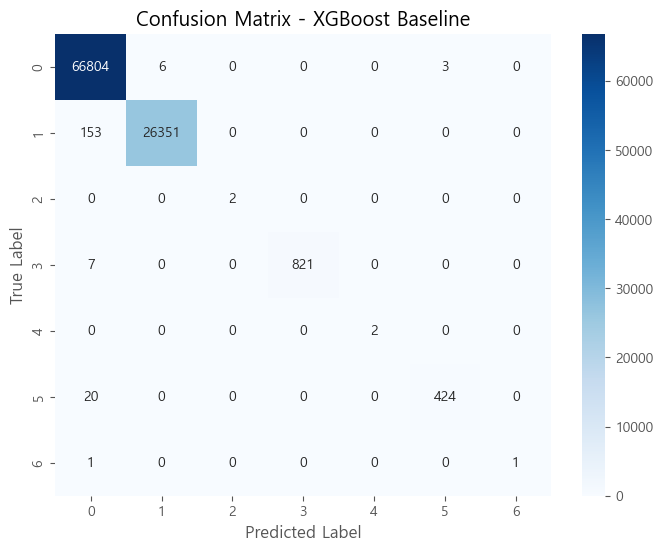

In [52]:
# 혼동 행렬을 계산합니다. labels로 라벨 순서를 0~6으로 고정합니다.
# 라벨을 고정하면 예측이 한 번도 안 된 level이 있어도 축에서 빠지지 않아,
# 희귀 level을 모델이 얼마나 못 맞히는지 그대로 확인할 수 있습니다.
labels_sorted = sorted(train["level"].unique())
cm = confusion_matrix(y_valid, valid_pred, labels=labels_sorted)

# 행(y축)=실제 정답, 열(x축)=모델 예측. 대각선이 진할수록 잘 맞힌 것입니다.
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title("Confusion Matrix - XGBoost Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [53]:
# 검증 단계에서는 데이터의 80%만 학습에 사용했습니다.
# 제출용 모델은 가지고 있는 학습 데이터를 모두 사용해 다시 학습하는 것이 일반적으로 더 좋습니다.

# 1) 최종 학습에 사용할 전체 입력/정답 (train_model 전체)
X_all = train_model["masked_log"]
y_all = train_model["level"]

# 2) TF-IDF를 전체 학습 데이터로 다시 fit 합니다. (검증 때와 동일한 설정)
final_tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    stop_words=['num', 'datetime', 'ip', 'hex', 'epoch']
)
# 학습 데이터는 fit_transform으로 단어 사전을 만들며 변환합니다.
X_all_tfidf = final_tfidf.fit_transform(X_all)
# 테스트 데이터는 transform만 사용합니다. fit_transform을 쓰면 데이터 누수가 되므로 주의합니다.
X_test_tfidf = final_tfidf.transform(test["masked_log"])

print("X_all_tfidf  shape:", X_all_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_all_tfidf  shape: (472972, 20000)
X_test_tfidf shape: (1418916, 20000)


In [54]:
# 3) 최종 XGBoost 모델을 전체 학습 데이터로 학습합니다. (검증 때와 동일한 설정)
final_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_jobs=-1,
)
final_model.fit(X_all_tfidf, y_all)

# 4) 테스트 데이터를 예측합니다.
#    predict는 각 샘플에 대해 가장 확률이 높은 클래스(level 0~6 중 하나)를 바로 돌려줍니다.
#    (각 클래스의 확률값 자체가 필요할 때는 뒤의 선택 실험에서 predict_proba를 사용합니다.)
#    이 기본 예측값은 test_pred_basic 으로 따로 두어, 뒤의 선택 실험 결과와 구분합니다.
test_pred_basic = final_model.predict(X_test_tfidf)
print("최종 모델 학습 및 test 예측 완료")
print("예측 결과 개수:", len(test_pred_basic))
print("예측된 level 분포:", pd.Series(test_pred_basic).value_counts().sort_index().to_dict())

최종 모델 학습 및 test 예측 완료
예측 결과 개수: 1418916
예측된 level 분포: {0: 1004230, 1: 395231, 2: 34, 3: 12910, 4: 33, 5: 6459, 6: 19}


In [55]:
# ============================================================
# 선택 실험: 예측 확률이 낮은 샘플을 level 7로 변경하기
# 이 셀은 기본 학습이 아니라 선택 후처리 실험입니다. 기본 제출과 구분합니다.
# ============================================================

# predict_proba는 각 샘플이 클래스(0~6)에 속할 예측 확률을 모두 돌려줍니다.
# (predict는 이 중 가장 큰 확률의 클래스 하나만 돌려줍니다.)
test_proba = final_model.predict_proba(X_test_tfidf)

# 각 샘플에서 가장 높은 클래스 확률을 구합니다.
# 이 값은 모델이 자신의 예측을 얼마나 확신하는지 확인하는 데 사용합니다.
max_proba = np.max(test_proba, axis=1)

# THRESHOLD: 기존 예측을 유지할 최소 확신 기준입니다.
# 최대 예측 확률이 이 값보다 낮은 샘플은 모델이 충분히 확신하지 못한 것으로 보고 level 7로 바꿉니다.
# 주의: 0.5는 정답값이 아니라 실험 시작값입니다. (threshold 값에 따라 결과가 달라집니다.)
THRESHOLD = 0.5

# 기본 예측을 복사한 뒤, 확신도가 낮은 샘플만 level 7로 바꿉니다. (기본 예측값은 그대로 보존)
test_pred_with_7 = test_pred_basic.copy()
test_pred_with_7[max_proba < THRESHOLD] = 7

print("[기본 예측 분포]")
print(pd.Series(test_pred_basic).value_counts().sort_index())

print("\n[level 7 후처리 적용 후 예측 분포]")
print(pd.Series(test_pred_with_7).value_counts().sort_index())

print("\nlevel 7로 변경된 개수:", (test_pred_with_7 == 7).sum())
print("전체 test 개수:", len(test_pred_with_7))
print("level 7 비율:", (test_pred_with_7 == 7).mean())

[기본 예측 분포]
0    1004230
1     395231
2         34
3      12910
4         33
5       6459
6         19
Name: count, dtype: int64

[level 7 후처리 적용 후 예측 분포]
0    1004109
1     395182
2         34
3      12909
4         33
5       6450
6         19
7        180
Name: count, dtype: int64

level 7로 변경된 개수: 180
전체 test 개수: 1418916
level 7 비율: 0.000126857403820945


In [56]:
# ============================================================
# threshold 값에 따른 level 7 예측 개수 비교
# ============================================================

threshold_list = [0.5, 0.6, 0.7, 0.8, 0.9]

threshold_summary = []

for threshold in threshold_list:
    temp_pred = test_pred_basic.copy()
    temp_pred[max_proba < threshold] = 7

    threshold_summary.append({
        "threshold": threshold,
        "level_7_count": int((temp_pred == 7).sum()),
        "level_7_ratio": float((temp_pred == 7).mean()),
    })

threshold_summary = pd.DataFrame(threshold_summary)

display(threshold_summary)

,threshold,level_7_count,level_7_ratio
0,0.5,180,0.000127
1,0.6,1060,0.000747
2,0.7,5858,0.004129
3,0.8,7295,0.005141
4,0.9,7746,0.005459


In [57]:
# ============================================================
# 제출에 사용할 예측값 선택
# ============================================================

# 기본 baseline 제출값: level 0~6만 예측
# test_pred_for_submission = test_pred_basic

# level 7 후처리를 적용하고 싶으면 아래 줄의 주석을 해제하고,
# 위 줄을 주석 처리하세요.
test_pred_for_submission = test_pred_with_7

print("최종 제출에 사용할 예측값 분포:")
print(pd.Series(test_pred_for_submission).value_counts().sort_index())

최종 제출에 사용할 예측값 분포:
0    1004109
1     395182
2         34
3      12909
4         33
5       6450
6         19
7        180
Name: count, dtype: int64


In [58]:
# sample_submission을 복사해서 제출 형식(행 개수, 컬럼)을 그대로 유지합니다.
submission = sample_submission.copy()

# sample_submission 의 컬럼 구조를 먼저 확인합니다.
print("sample_submission 컬럼:", sample_submission.columns.tolist())

# 일반적으로 sample_submission의 "마지막 컬럼"이 예측값을 넣는 컬럼입니다.
# 이 대회의 sample_submission은 ['id', 'level'] 구조라서 마지막 컬럼이 'level'입니다.
# columns[-1] 방식은 컬럼명이 달라도 동작하도록 일반화한 것이며, 대회마다 컬럼명을 직접 확인합니다.
target_col = submission.columns[-1]
print("예측값을 넣을 컬럼:", target_col)

# sample_submission의 마지막 컬럼에 어떤 값들이 들어있는지 예시로 확인합니다.
# (단, sample_submission만으로 모든 허용 label을 알 수는 없습니다. 대회 설명을 확인하세요.)
print("sample_submission 마지막 컬럼 고유값 예시:")
print(sample_submission[target_col].unique()[:20])

# 행 개수가 test 데이터와 같은지 확인합니다. (제출 파일은 test와 행 개수가 같아야 합니다.)
print("test 행 개수:", len(test))
print("submission 행 개수:", len(submission))

# 예측 결과를 제출 파일의 예측 컬럼(level)에 저장합니다. (반드시 test_pred_for_submission 사용)
submission[target_col] = test_pred_for_submission

# 안전 확인: 제출 파일과 test의 행 개수가 같아야 합니다.
assert len(submission) == len(test), "submission과 test의 행 개수가 다릅니다."

# 제출 예측값 분포 확인 (특정 클래스만 과도하게 예측되는지 점검)
print("\n제출 예측값 분포:")
print(submission[target_col].value_counts().sort_index())

# 저장 (한글/엑셀 호환을 위해 utf-8-sig)
submission.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

# 저장된 CSV 파일을 데이콘 제출 페이지에 업로드하면 됩니다.
print(f"\n제출 파일이 저장되었습니다: {OUTPUT_PATH}")
display(submission.head())

sample_submission 컬럼: ['id', 'level']
예측값을 넣을 컬럼: level
sample_submission 마지막 컬럼 고유값 예시:
[0]
test 행 개수: 1418916
submission 행 개수: 1418916

제출 예측값 분포:
level
0    1004109
1     395182
2         34
3      12909
4         33
5       6450
6         19
7        180
Name: count, dtype: int64

제출 파일이 저장되었습니다: base_log2.csv


,id,level
0,1000000,0
1,1000001,0
2,1000002,1
3,1000003,0
4,1000004,1


## 18. baseline 이후 추가 실험

이 baseline을 출발점으로 삼아, 아래 항목들을 직접 실험하며 결과를 비교해 보세요. 실험은 **필수 → 선택 → 확장** 순서로 난이도가 올라갑니다.

각 실험에서 공통으로 확인할 점:

- accuracy만 보지 말고 **macro F1과 level별 recall**을 함께 확인합니다.
- **로컬 검증 점수와 데이콘 public score**가 비슷한 방향으로 움직이는지 확인합니다.
- 무엇을 바꿨을 때 결과가 어떻게 달라졌는지 기록합니다.

### 필수 실험

1. TF-IDF의 `max_features` 값을 바꿔보고 Macro F1을 비교합니다.
2. TF-IDF의 `ngram_range` 값을 바꿔보고 Macro F1을 비교합니다.
3. confusion matrix를 보고 어떤 level에서 오분류가 많은지 정리합니다.

세부 항목:

- TF-IDF 옵션: `max_features`, `ngram_range`, `min_df`, `max_df`, `sublinear_tf`
  - 예: `max_features` 5000 vs 10000, `ngram_range` (1, 1) vs (1, 2) vs (2, 2)
- XGBoost 하이퍼파라미터: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `reg_alpha`, `reg_lambda`
  - 한 번에 너무 많은 파라미터를 바꾸지 말고, 무엇을 바꿨을 때 결과가 변했는지 확인합니다.
- 결과 해석: support가 작은 level의 recall을 확인하고, confusion matrix에서 어떤 level을 어떤 level로 잘못 예측했는지 분석합니다.

### 선택 실험

1. `sublinear_tf=True/False` 를 비교합니다.
2. XGBoost의 `max_depth` 또는 `n_estimators` 를 변경해 봅니다.
3. CountVectorizer와 TF-IDF 결과를 비교합니다.
   - `CountVectorizer`, `CountVectorizer + TfidfTransformer`, `TfidfVectorizer` 를 비교합니다.
4. 다른 모델과 결과를 비교합니다.
   - LogisticRegression, LinearSVC, RandomForest, ExtraTreesClassifier, LightGBM 등
   - 어떤 모델의 macro F1과 public score가 좋은지, 학습 시간은 적절한지 확인합니다.

### 확장 실험

1. 로그 마스킹 전처리를 실험합니다.
   - 숫자, IP, 날짜/시간 등을 단순 삭제하기보다 의미 있는 토큰으로 치환해 봅니다.
   - IP → `<IP>`, 날짜 → `<DATE>`, 시간 → `<TIME>`, 날짜+시간 → `<DATETIME>`, 포트 → `<PORT>`, 일반 숫자 → `<NUM>`, 16진수 → `<HEX>`, 시리얼 번호처럼 보이는 문자열 → `<SN>`
   - 전처리 전후의 macro F1과 public score를 비교하고, 어떤 마스킹이 도움이 되었는지(또는 오히려 성능을 떨어뜨렸는지) 해석합니다.
2. level 7 threshold 후처리 실험을 비교합니다.
   - 이 노트북의 "선택 실험" 셀을 출발점으로, `THRESHOLD` 를 0.5 ~ 0.9로 바꿔가며 level 7 개수와 public score 변화를 비교합니다.
   - `level 7` 이 대회 규정상 허용되는 제출값인지 대회 설명을 확인합니다.
   - XGBoost 모델 자체는 0~6만 학습하고, 7은 사후 후처리 값이라는 점을 혼동하지 않습니다.
   - public score에만 과하게 맞추면 private score에서 성능이 떨어질 수 있습니다.
3. 클래스 불균형 대응을 실험합니다.
   - `sample_weight` 또는 `class_weight` 를 적용하고, 희귀 level의 recall과 macro F1 변화를 확인합니다.
   - 다수 클래스 성능이 지나치게 떨어지지 않는지 함께 확인합니다.
4. 여러 모델의 결과를 비교하거나 결합해 봅니다.
   - 여러 모델의 예측 확률을 평균내는 앙상블을 실험하고, 단일 모델보다 안정적인지 확인합니다.
5. 토큰화 기반 딥러닝 모델을 적용해 봅니다.
   - Embedding + LSTM, CNN + BiLSTM, 1D-CNN 등
   - 학습 시간이 오래 걸릴 수 있고 GPU 환경이 필요할 수 있으므로, 처음에는 일부 데이터로 실험합니다.

## 19. 실행 시간이 오래 걸릴 때 조정할 수 있는 항목

이 baseline은 전체 train 데이터를 사용합니다.

실행 시간이 오래 걸릴 경우, 데이터를 임의로 샘플링하기보다 모델 복잡도와 TF-IDF feature 수를 먼저 줄이는 방식으로 조정합니다.

조정 가능한 항목은 다음과 같습니다.

- `TfidfVectorizer(max_features=5000)` 에서 `max_features` 를 더 작게 줄이기
  - 예: 5000 → 3000 → 2000
- XGBoost의 `n_estimators` 줄이기
  - 예: 100 → 50
- XGBoost의 `max_depth` 줄이기
  - 예: 4 → 3

### 임시 설정 예시

예를 들어 TF-IDF를 아래처럼 줄일 수 있습니다.

```python
TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
)
```

또는 XGBoost 설정을 임시로 줄일 수 있습니다.

```python
XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
```

단, 위 설정은 **빠른 실험용 임시 값**입니다. 최종 데이콘 제출용 모델은 가능한 한 기존 baseline 설정(`max_features=5000`, `n_estimators=100`, `max_depth=4`) 또는 더 충분한 설정으로 다시 학습하는 것이 좋습니다.

## 20. 마무리 정리

- baseline 모델은 **성능 최고 모델이 아니라 시작점** 입니다.
- 데이콘 점수를 높이려면 **로컬 검증 성능과 제출 점수를 함께** 확인해야 합니다.
- **public score에만 과하게 맞추면 private score에서 성능이 떨어질 수 있습니다.** (과적합 주의)
- 좋은 실험은 단순히 점수가 높은 것이 아니라, **무엇을 바꿨고 왜 성능이 변했는지 설명**할 수 있어야 합니다.
- 불균형 다중분류에서는 accuracy보다 **macro F1, class별 recall, confusion matrix 해석**이 중요합니다.
- 데이터 성격을 이해하기 위한 EDA는, 결국 **모델 개선 아이디어**를 얻기 위한 과정입니다.
- 이제 baseline을 기준으로 전처리, TF-IDF 옵션, 모델 파라미터, 다른 모델, 앙상블, LSTM 등 다양한 실험을 진행해 보세요. 🚀